# Model for Predicting Weekly Walmart Sales

This notebook shows the process of creating a linear regression model to predict the weekly sales of a Walmart store using unorthodox features such as air temperature, fuel price, and unemployment rates.

More concretely, the steps to take in order to create the model are:
1. Exploratory Data Analysis of the elements in the dataset
2. Definition of a preprocessing pipeline
3. Linear Regression model training
4. Performance evaluation of the trained model
5. Serialization of the model, including the preprocessing pipeline

The dataset was sourced from Kaggle and can be found here: https://www.kaggle.com/datasets/mikhail1681/walmart-sales

## Exploratory Data Analysis

In [1]:
# Import the necessary libraries and methods

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error, r2_score

In [2]:
# Load the dataset as a pandas DataFrame

data = pd.read_csv("dataset/Walmart_Sales.csv")
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


The `Store` column will be dropped. The only insight the store number could give us would be regional variations already described by the other columns.

The `Date` column will be preemptively modified to only contain information about the month. The exact week is not very useful for our prediction model, but the time of the year (as represented by the month that the week happens to fall in) might be.

In [3]:
data['Date'] = pd.to_datetime(data['Date'], format="%d-%m-%Y")
data['Midweek'] = data['Date'] + pd.Timedelta(days=3)
data['Month'] = data['Midweek'].dt.month
data = data.drop(columns=['Store', 'Midweek'])
data

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month
0,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2
1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2
2,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2
3,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,3
4,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3
...,...,...,...,...,...,...,...,...
6430,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,10
6431,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,10
6432,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,10
6433,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,10


Now we will visualize the features and our target label in order to give us an idea of the kind of preprocessing we should do.

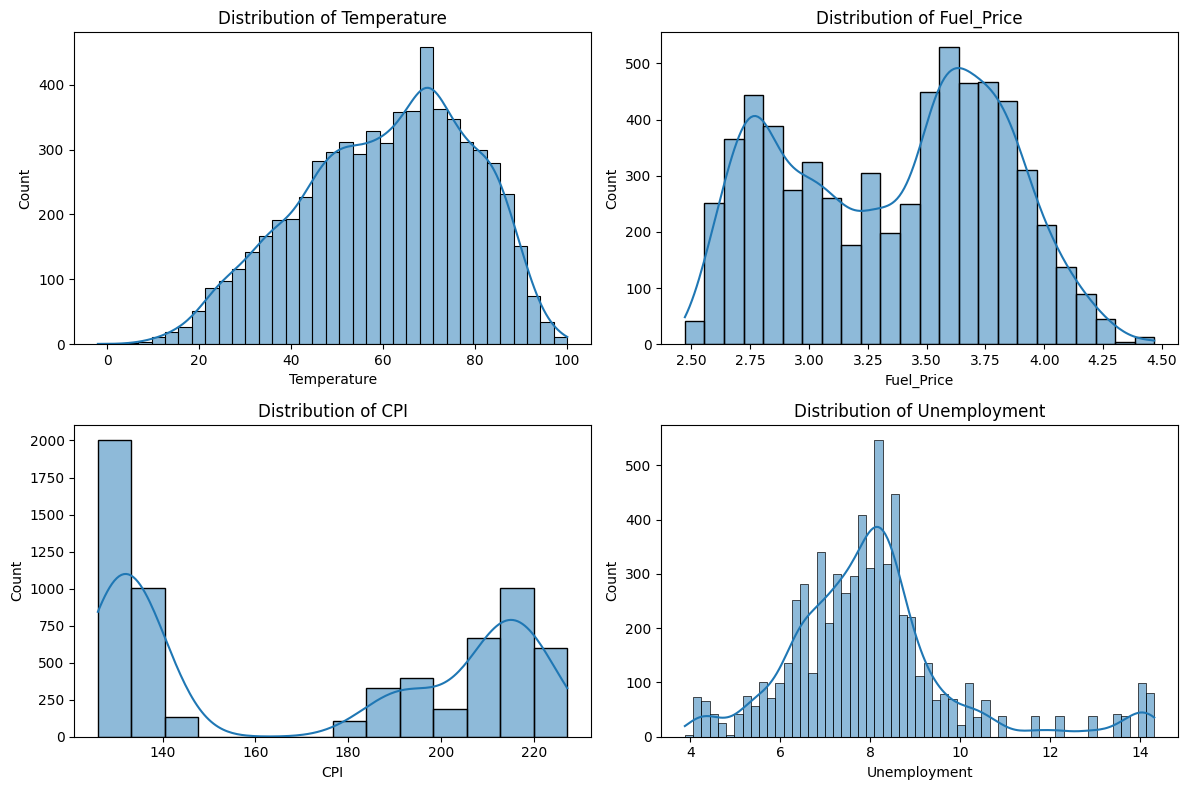

In [4]:
# Visualization of numerical features

numerical_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
fig.tight_layout()

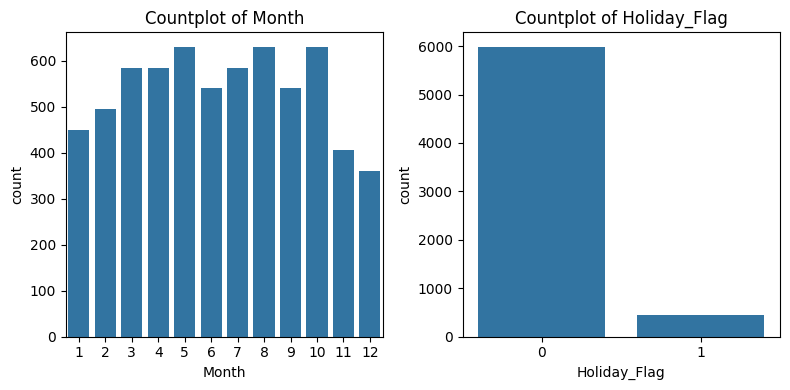

In [5]:
# Visualization of categorical features

categorical_cols = ['Month', 'Holiday_Flag']

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axs.ravel(), categorical_cols):
    sns.countplot(data=data, x=col, ax=ax)
    ax.set_title(f'Countplot of {col}')
fig.tight_layout()

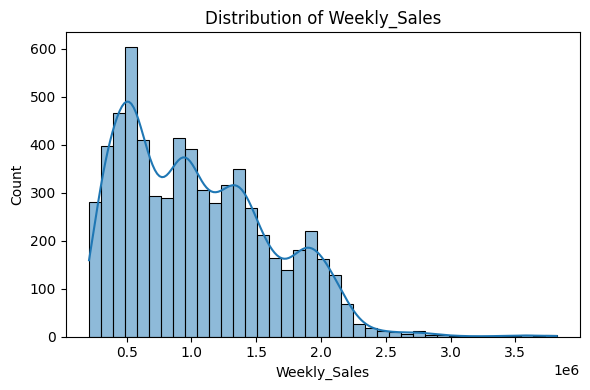

In [6]:
# Visualization of target label distribution

fig = plt.figure(figsize=(6, 4))
sns.histplot(data['Weekly_Sales'], kde=True)
plt.title('Distribution of Weekly_Sales')
plt.tight_layout()

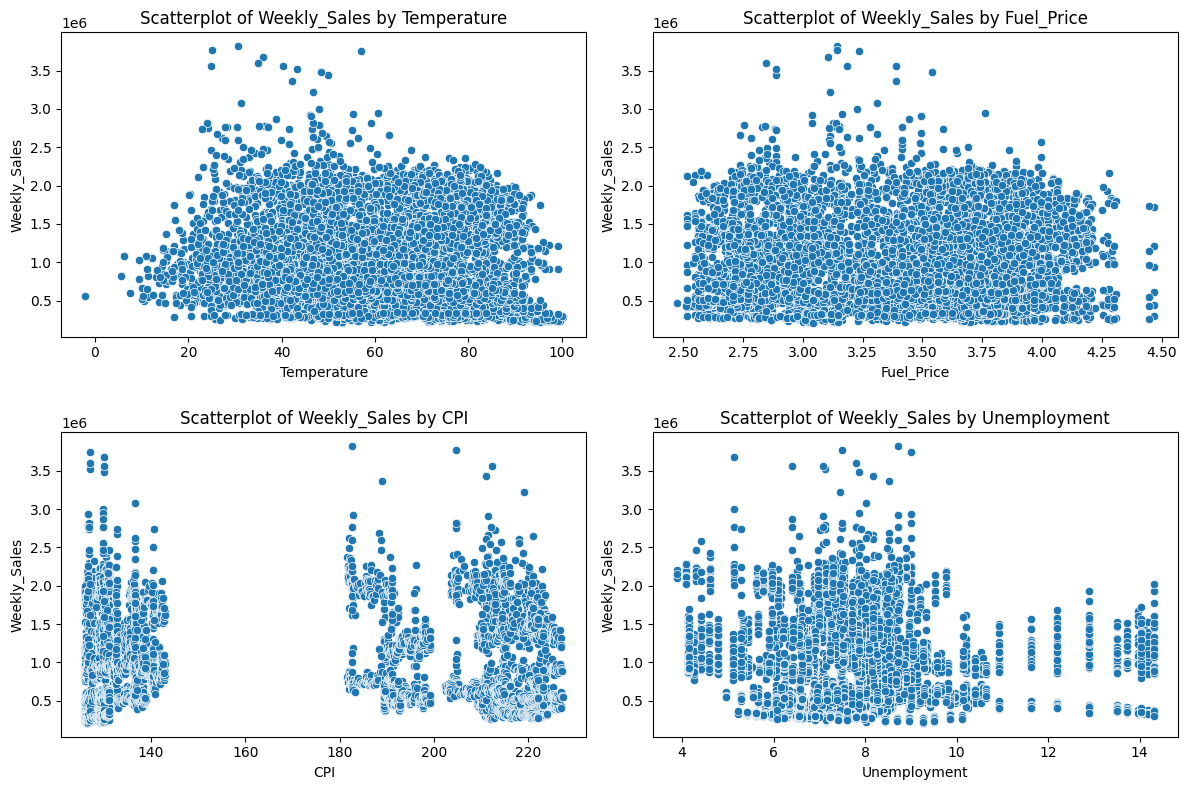

In [7]:
# Scatterplots of target label against numerical features

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axs.ravel(), numerical_cols):
    sns.scatterplot(data=data, x=col, y='Weekly_Sales', ax=ax)
    ax.set_title(f'Scatterplot of Weekly_Sales by {col}')
fig.tight_layout()

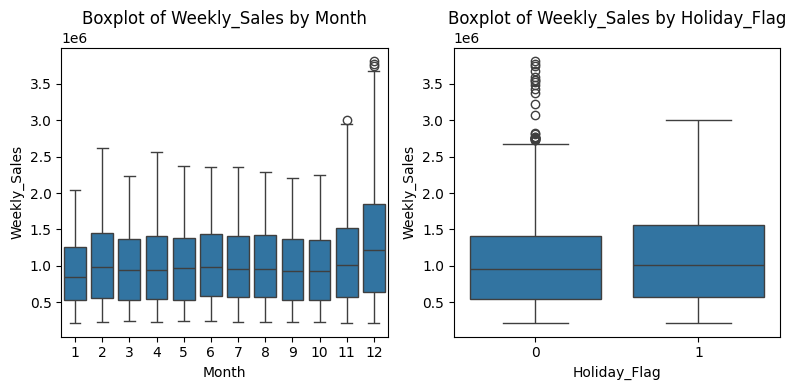

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axs.ravel(), categorical_cols):
    sns.boxplot(data=data, x=col, y='Weekly_Sales', ax=ax)
    ax.set_title(f'Boxplot of Weekly_Sales by {col}')
fig.tight_layout()

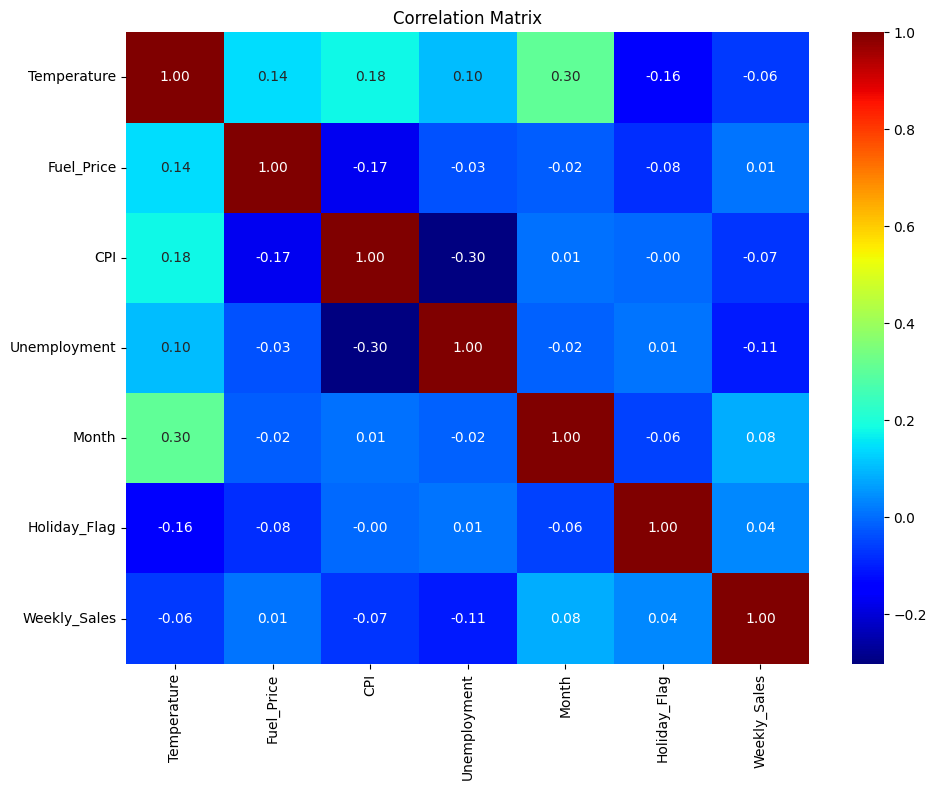

In [9]:
correlation_cols = numerical_cols + categorical_cols + ['Weekly_Sales']
corr_matrix = data[correlation_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='jet', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

I believe there are two things to note looking at these graphs.

First, the `CPI` feature is very stratified, that is to say the datapoints all belong to very specific clusters of values. We can see it best in the graph comparing `Weekly_Sales` to `CPI`. They all form three distinct clusters, which I believe comes from the specific choice of stores that were included in the dataset, with certain regions simply having different CPI baselines. Locally, it seems like `Weekly_Sales` and `CPI` do have a sort of inverse relationship which would be useful to include in our model, and that can be seen reflected in the correlation matrix as well. Originally, this paragraph was going to lead me to drop the column, but I come from the future and the model including the column does better so we are not going to do that.

Next is the strong correlation that `Temperature` has with the other features, which in cases like with `Month` and `Holiday_Flag` makes sense. This coupled with the fact that our target `Weekly_Sales` doesn't appear to have much relation to the other features makes me wonder if our model will be at all effective. Hopefully the whole is greater than the sum of its parts.

That being said, and before moving onto making the preprocessing pipeline, we will check for missing values.

In [10]:
missing_counts = data.isnull().sum()
missing_counts

,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
Month,0


Good news! We don't have to impute anything.

## Preprocessing Pipeline

This time around the preprocessing pipeline will be extremely simple. The only thing needed is to apply standard scaling to the numerical columns. The categorical columns don't need encoding as they are already represented as numbers.

In [11]:
preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), ['Temperature', 'Fuel_Price', 'Unemployment', 'CPI']),
        ],
        remainder='passthrough', # Pass through any remaining columns without changes
        force_int_remainder_cols=False
    )
)

Next, we define our feature matrix `x`, target vector `y`, and split them 80-20 into training and testing sets.

In [12]:
x = data.drop(columns=['Date', 'Weekly_Sales'])
y = data["Weekly_Sales"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=56)

## Linear Regression Model Training

We will create the full pipeline by including the preprocessing steps before the linear regression model in order to handle raw input data. Following that, the model will be fit to the training data.

In [13]:
regression_model = make_pipeline(
    preprocessing_pipeline,
    LinearRegression()
)
regression_model

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('num',
                                                                   StandardScaler(),
                                                                   ['Temperature',
                                                                    'Fuel_Price',
                                                                    'Unemployment',
                                                                    'CPI'])]))])),
                ('linearregression', LinearRegression())])

In [14]:
regression_model.fit(x_train, y_train)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    remainder='passthrough',
                                                    transformers=[('num',
                                                                   StandardScaler(),
                                                                   ['Temperature',
                                                                    'Fuel_Price',
                                                                    'Unemployment',
                                                                    'CPI'])]))])),
                ('linearregression', LinearRegression())])

## Performance Evaluation

To evaluate how our model performed, we will compare the predicted labels with the actual labels from the test set. Specifically, I have decided to utilize the following two metrics.

1. Root Mean Squared Error (RMSE): This will tell us how far off our model was at predicting the correct value on average. We are already working with values in the millions, so RMSE will let us keep the same units.
2. R²: This will tell us the proportion of the variance present in the target label that can be explained by our model.

In [15]:
def evaluate_model(model, x, y):
  y_pred = model.predict(x)
  rmse = root_mean_squared_error(y, y_pred)
  r2 = r2_score(y, y_pred)
  return {"RMSE": rmse, "R2": r2}

In [16]:
train_eval = evaluate_model(regression_model, x_train, y_train)
test_eval = evaluate_model(regression_model, x_test, y_test)

eval_df = pd.DataFrame({"Train": train_eval, "Test": test_eval})
eval_df.T

,RMSE,R2
Train,557667.915176,0.033925
Test,542377.704744,0.034135


So that's a really bad prediction model. The error is pretty egregious and the R² metric tells us that our features don't explain much of anything. This is basically no better than making an educated guess. I do believe the information in this dataset could definitely be used for predicting weekly sales, it just so happens that the way we went about it here was most assuredly not the best.

In hindsight I could've probably chosen a different model that wasn't linear regression and it would've given us much better results, or at least I think so, but it's too late now to scrap the whole thing and use decision trees instead, so let's keep going.

## Serialization

In this last step, we will dump the pipeline containing the preprocessing steps and the trained model into a joblib object that we can then use in another project to realize (bad) predictions.

In [17]:
joblib.dump(regression_model, "model/Walmart_Sales.joblib")

['model/Walmart_Sales.joblib']